In [10]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('climate_jakarta_96745.csv')

df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds')

df.head()

,ds,y
0,2010-01-01,28.7
1,2010-01-02,28.7
2,2010-01-03,28.8
3,2010-01-04,29.9
4,2010-01-05,28.5


In [12]:
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.1)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size+val_size]
test = df.iloc[train_size+val_size:]

len(train), len(val), len(test)

(2802, 400, 802)

In [13]:
model = NeuralProphet(
    n_lags=30,
    n_forecasts=1,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    epochs=200,
    learning_rate=1.0
)

In [14]:
metrics = model.fit(train, validation_df=val, progress='bar')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.929% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.data.processing._handle_missing_data) - Added 1 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 1 NaN values in column y were auto-imputed.
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [15]:
future = model.make_future_dataframe(train, periods=len(test), n_historic_predictions=True)
forecast = model.predict(future)

y_pred = forecast['yhat1'].tail(len(test)).values
y_true = test['y'].values

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.929% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.929% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.929% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 1 missing dates.
INFO - (NP.data.processing._handle_missing_data) - Dropped 1 rows at the end with NaNs in 'y' column.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing val

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [16]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100
naive = np.mean(np.abs(np.diff(train['y'])))
mase = mae / naive

print('RMSE :', rmse)
print('MAE  :', mae)
print('sMAPE:', smape)
print('MASE :', mase)

RMSE : 1.185182013814072
MAE  : 0.9662179233427357
sMAPE: 3.3739092987929875
MASE : 1.3985718584481435


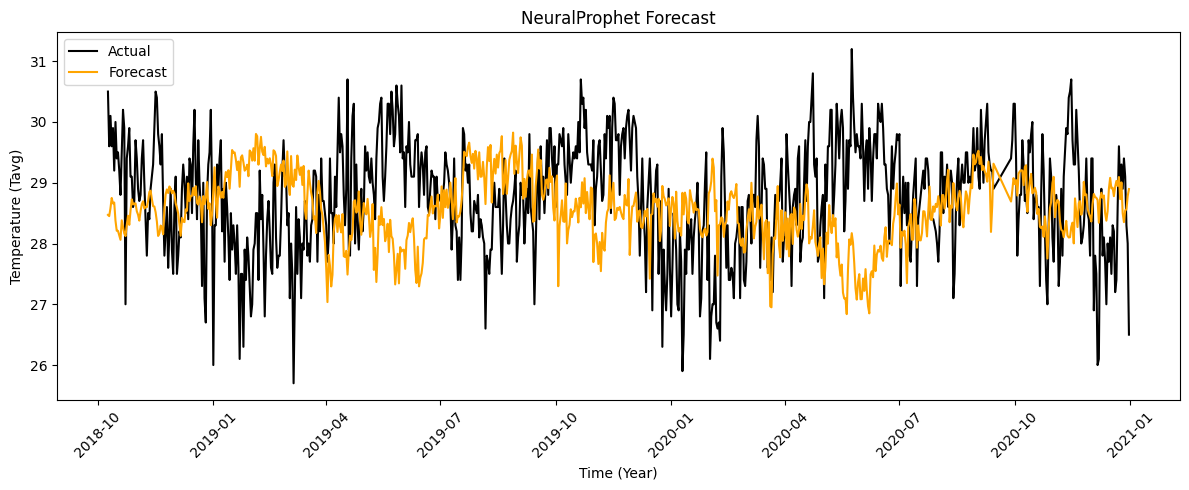

In [17]:
ds_test = test["ds"].iloc[:len(y_true)]

plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label="Actual", color="black")
plt.plot(ds_test, y_pred, label="Forecast", color="orange")

plt.title("NeuralProphet Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Temperature (Tavg)")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()